<pre>
Load Data
↓
Select Alternative Proxies
↓
EDA
↓
Handle Missing Data
↓
Encoding (One-Hot)
↓
Train/Test Split
↓
SMOTE (train only)
↓
Train XGBoost
↓
Evaluate Model
↓
Explain using SHAP
</pre>

C:\Users\Rushi\AppData\Local\Temp\ipykernel_19640\772789695.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


Class Imbalance Check (0: Good, 1: Risk):
Category
0    0.7
1    0.3
Name: proportion, dtype: float64


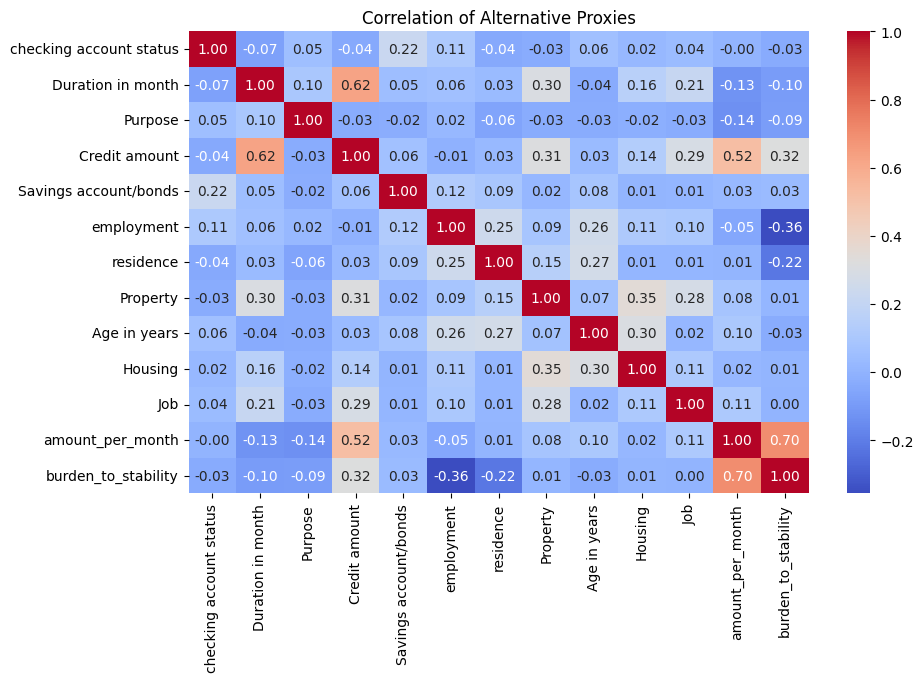

Cross-Validated ROC-AUC: 0.7782380952380952

Final Model Insights (SHAP):


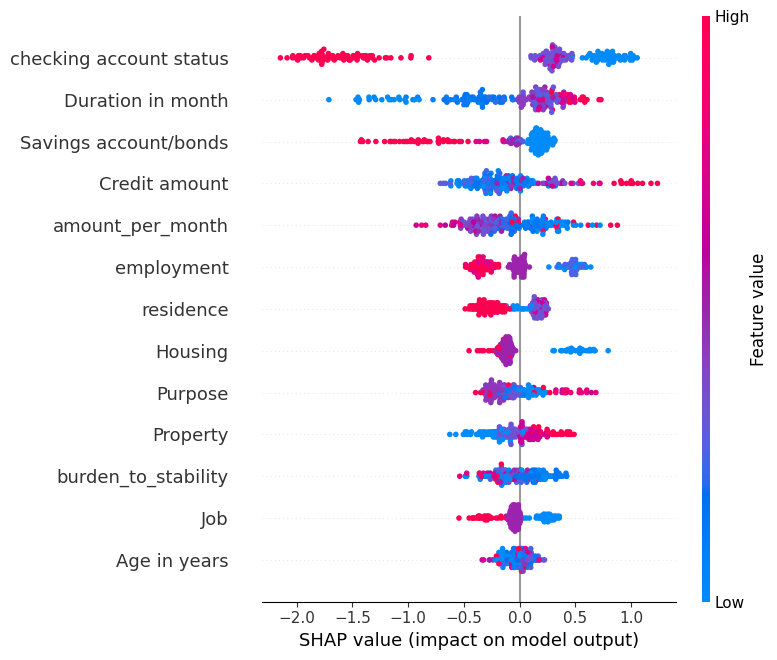

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
from sklearn.model_selection import cross_val_score

# --- 1. LOAD DATA ---
# Ensure your file name matches exactly
df = pd.read_csv('german_credit_data.csv') 

# --- 2. ATTRIBUTE SELECTION (The "Unbanked" Strategy) ---
# We select columns that act as proxies for reliability without a bank account.
# We DROP 'status n sex' and 'foreign worker' to ensure the model is UNBIASED.
proxies = [
    'checking account status', 'Duration in month', 'Purpose', 
    'Credit amount', 'Savings account/bonds', 'employment', 
    'residence', 'Property', 'Age in years', 'Housing', 'Job'
]

X = df[proxies].copy()
# In UCI, 1 = Good, 2 = Bad. We map them to 0 (Good) and 1 (Bad/Risk)
y = df['Category'].map({1: 0, 2: 1})

# --- 3. PRE-PROCESSING (Label Encoding) ---
# UCI uses codes like A11, A12. We convert these to numbers.

encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# --- FEATURE ENGINEERING ---

X['amount_per_month'] = X['Credit amount'] / X['Duration in month']
X['burden_to_stability'] = X['amount_per_month'] / ((X['employment'] + 1) * (X['residence'] + 1))

# --- 4. EDA (Step 2 of your Workflow) ---
print("Class Imbalance Check (0: Good, 1: Risk):")
print(y.value_counts(normalize=True))

# Heatmap to check for redundant attributes
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation of Alternative Proxies")
plt.show()

# --- 5. SMOTE & TRAINING (Step 4 & 7 of your Workflow) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Applying SMOTE to handle the minority 'Risk' class
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Training the XGBoost Model
# model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')
model = XGBClassifier(n_estimators=300, learning_rate=0.03, max_depth=4, subsample=0.8, colsample_bytree=0.8, gamma=1, min_child_weight=3, random_state=42, eval_metric='logloss')
model.fit(X_train_bal, y_train_bal)

# Cross-Validation to check for overfitting (5 splits instead of 1 split)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')

print("Cross-Validated ROC-AUC:", cv_scores.mean())

# --- 6. EXPLAINABILITY (SHAP) ---
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Final Output: Visualizing which 'Alternative' data point mattered most
print("\nFinal Model Insights (SHAP):")
shap.summary_plot(shap_values, X_test)

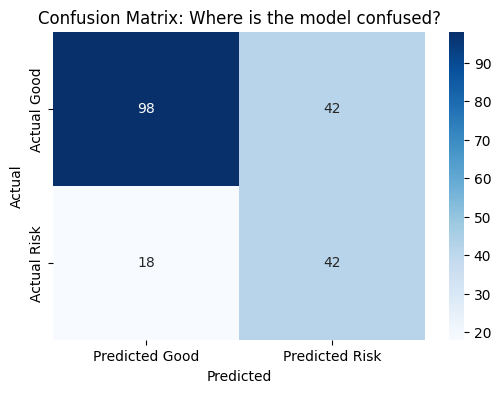

              precision    recall  f1-score   support

           0       0.84      0.70      0.77       140
           1       0.50      0.70      0.58        60

    accuracy                           0.70       200
   macro avg       0.67      0.70      0.67       200
weighted avg       0.74      0.70      0.71       200

ROC-AUC Score: 0.7772619047619048


In [26]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score

# 1. Get predictions
# y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# tuned threshold
threshold = 0.4
y_pred = (y_prob > threshold).astype(int)

# 2. Create the matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot it nicely
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Good', 'Predicted Risk'],
            yticklabels=['Actual Good', 'Actual Risk'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Where is the model confused?')
plt.show()

# 4. Print the text report (Precision, Recall, F1)
print(classification_report(y_test, y_pred))

probs = model.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, probs))

In [27]:
import joblib
# Save the model
joblib.dump(model, 'credit_model.pkl')
# Save your encoders (so the app knows 'Rent' = 1)
joblib.dump(encoders, 'encoders.pkl')
# Save Column Order (so the app knows which columns to expect)
joblib.dump(X.columns.tolist(), "model_columns.pkl")
# Create Label Meaning Dictionary (so the app can show 'Rent' instead of 'A151')
label_maps = {

    "Housing": {
        "A151": "Rent",
        "A152": "Own House",
        "A153": "Free Housing"
    },

    "checking account status": {
        "A11": "Balance < 0",
        "A12": "Balance 0–200",
        "A13": "Balance ≥ 200",
        "A14": "No Checking Account"
    },

    "Savings account/bonds": {
        "A61": "Savings < 100",
        "A62": "Savings 100–500",
        "A63": "Savings 500–1000",
        "A64": "Savings ≥ 1000",
        "A65": "No Savings / Unknown"
    },

    "Purpose": {
        "A40": "Car (New)",
        "A41": "Car (Used)",
        "A42": "Furniture / Equipment",
        "A43": "Radio / TV",
        "A44": "Domestic Appliances",
        "A45": "Repairs",
        "A46": "Education",
        "A47": "Vacation",
        "A48": "Retraining",
        "A49": "Business",
        "A410": "Other"
    },

    "Job": {
        "A171": "Unemployed / Unskilled",
        "A172": "Unskilled (Resident)",
        "A173": "Skilled Worker",
        "A174": "Highly Skilled / Management"
    },

    "employment": {
        "A71": "Unemployed",
        "A72": "< 1 year",
        "A73": "1–4 years",
        "A74": "4–7 years",
        "A75": "7+ years"
    },

    "Property": {
        "A121": "Real Estate",
        "A122": "Savings / Insurance",
        "A123": "Car or Other Assets",
        "A124": "No Property"
    }
}
joblib.dump(label_maps, "label_maps.pkl")


['label_maps.pkl']